# When Traditional Notebook Systems Break Down


## Import the libraries

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import time


## Define a function

In [7]:
def compound_interest(principal, rate, years):
    """Calculate compound interest year by year."""
    values = [principal]
    for year in range(1, years + 1):
        values.append(values[-1] * (1 + rate))
    return values


## Set parameters for one scenario

In [8]:
principal = 1000
rate = 0.07
years = 20


### Out-of-order execution

Now do this deliberately:

1. Change `years = 20` to `years = 50`.
2. Re-run **only** the parameters cell.

Now the notebook is inconsistent:

- the code on screen says `years = 50`
- the printed result still reflects 20 years
- the plot title is for 20 years

A careful user can fix this by manually re-running everything downstream.
The problem is that Jupyter does **not** know what downstream means. It gives you no protection if you forget.

## Compute the growth path

In [9]:
growth = compound_interest(principal, rate, years)
print(f"${growth[-1]:,.2f}")


$3,869.68


## Plot the growth curve

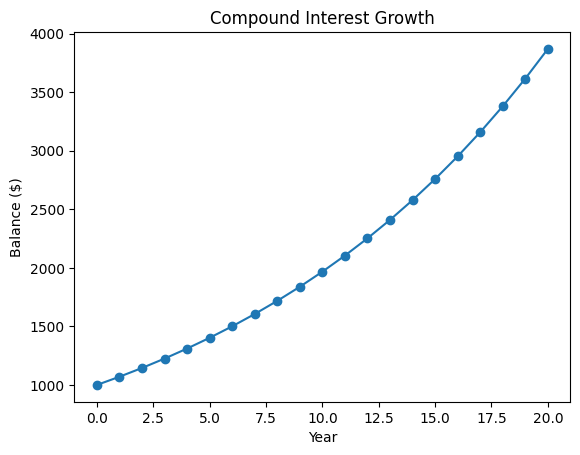

In [10]:
plt.plot(range(years + 1), growth, marker="o")
plt.xlabel("Year")
plt.ylabel("Balance ($)")
plt.title("Compound Interest Growth")
plt.show()


## Build a summary table

In [11]:
rates = [0.03, 0.05, 0.07, 0.10]
summary = []

for r in rates:
    scenario_growth = compound_interest(principal, r, years)
    summary.append({"rate": f"{r:.0%}", "years_used": years, "final_value": scenario_growth[-1]})

summary_df = pd.DataFrame(summary)
summary_df


,rate,years_used,final_value
0,3%,20,1806.111235
1,5%,20,2653.297705
2,7%,20,3869.684462
3,10%,20,6727.499949


## Simulate an expensive downstream step

This is the kind of cell people often avoid re-running after changing an input.

In [12]:
# print("Simulating an expensive downstream computation...")
# time.sleep(20)
# report = {
#     "years_used": years,
#     "recommended_message": f"At {rate:.0%}, holding for {years} years reaches ${growth[-1]:,.2f}."
# }
# print(report)


### Hidden state

Now try the second failure mode:

1. Delete the `compound_interest()` function cell.
2. Do **not** restart the kernel.
3. Re-run the compute cell or summary cell.

They can still work because the function is still alive in memory, even though it no longer exists in the notebook. Then restart the kernel and run all. Now the notebook fails, because the function was missing the whole time. That is hidden state.

In [13]:
compound_interest

<function __main__.compound_interest(principal, rate, years)>